# MS4 Algorithm 02FA Analysis

Special voice algorithm used by 2 MS4 programs: dstring3 and dkvoi1.
This appears to be a specialized string/voice variant.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from sam8905_interpreter import (
    SAM8905Interpreter,
    plot_waveform,
    export_wav,
    print_state,
)
from sam8905_aram_decoder import decode_algorithm, analyze_dram_usage
from ms4_programs import ALGORITHMS, PROGRAMS_02FA

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Algorithm Decode

Disassemble the A-RAM instructions and analyze D-RAM usage.

In [2]:
# Load algorithm
aram_02fa = ALGORITHMS['02FA']

# Decode and display
print(decode_algorithm(aram_02fa))

# D-RAM usage analysis
print("\nD-RAM Usage:")
usage = analyze_dram_usage(aram_02fa)
for addr, counts in sorted(usage.items()):
    print(f"  D[{addr:2d}]: read={counts['read']}, write={counts['write']}")


PC00: 79F5  RM 15, <WXY, WWF, WSP> ***
PC01: 38EF  RM 7, <WPHI>
PC02: 50F7  RM 10, <WXY>
PC03: 487F  RM 9, <WA>
PC04: 7CBF  RP, <WB>
PC05: 58FD  RM 11, <WWF>
PC06: 4AD7  RADD 9, <WM, WXY>
PC07: 407F  RM 8, <WA>
PC08: 7CBF  RP, <WB>
PC09: 42CF  RADD 8, <WM, WPHI>
PC10: 28B7  RM 5, <WB, WXY>
PC11: 307F  RM 6, <WA>
PC12: 2BDF  RADD 5, <WM, WSP> ***
PC13: 11EF  RM 2, <WPHI, WSP> ***
PC14: 60FD  RM 12, <WWF>
PC15: 086E  RM 1, <WA, WPHI, WACC>
PC16: 00BF  RM 0, <WB>
PC17: 0ADF  RADD 1, <WM>
PC18: 113F  RM 2, <WA, WB, WSP> ***
PC19: 12DF  RADD 2, <WM>
PC20: 18BF  RM 3, <WB>
PC21: 13DF  RADD 2, <WM, WSP> ***
PC22: 407F  RM 8, <WA>
PC23: 48BF  RM 9, <WB>
PC24: 20F7  RM 4, <WXY>
PC25: 7A7F  RADD, <WA>
PC26: 7CBF  RP, <WB>
PC27: 52DF  RADD 10, <WM>
PC28: 7FFF  RSP, <WSP> ***
PC29: 7FFF  RSP, <WSP> ***
PC30: 7FFF  RSP, <WSP> ***
PC31: 7FFF  RSP, <WSP> ***

D-RAM Usage:
  D[ 0]: read=1, write=0
  D[ 1]: read=1, write=1
  D[ 2]: read=2, write=2
  D[ 3]: read=1, write=0
  D[ 4]: read=1, write=0
  D[

## Available Programs

List all programs using this algorithm.

In [3]:
print(f"Programs using algorithm 02FA ({len(PROGRAMS_02FA)} total):\n")
for i, prog in enumerate(PROGRAMS_02FA):
    print(f"{i:2d}. [{prog['idx']:2d}] {prog['name']:<12} slots={prog['slot_count']} "
          f"dram0=0x{prog['dram_entry0']['word']:04X}")
    
    # Show voice slots for these rare programs
    for j, slot in enumerate(prog['voice_slots']):
        data_hex = ' '.join(f'{b:02X}' for b in slot['data'])
        print(f"    Voice slot {j}: [{data_hex}]")

Programs using algorithm 02FA (2 total):

 0. [54] dstring3     slots=1 dram0=0x5402
    Voice slot 0: [D7 07 40 00 00 00 00]
 1. [55] dkvoi1       slots=1 dram0=0xB401
    Voice slot 0: [D7 07 40 00 00 00 00]


## Program Selection

In [4]:
# Select program by index (0 or 1)
PROGRAM_INDEX = 1  # 0=dstring3, 1=dkvoi1

prog = PROGRAMS_02FA[PROGRAM_INDEX]
print(f"Selected: {prog['name']} (MS4 program #{prog['idx']})")
print(f"  Flags: 0x{prog['flags']:02X}, Slots: {prog['slot_count']}")
print(f"  D-RAM entry0: word=0x{prog['dram_entry0']['word']:04X}")

# D-RAM stream
if prog['dram_stream']:
    print(f"\n  D-RAM stream ({len(prog['dram_stream'])} bytes):")
    for i in range(0, min(64, len(prog['dram_stream'])), 16):
        chunk = prog['dram_stream'][i:i+16]
        hex_str = ' '.join(f'{b:02X}' for b in chunk)
        print(f"    {i:3d}: {hex_str}")

Selected: dkvoi1 (MS4 program #55)
  Flags: 0x01, Slots: 1
  D-RAM entry0: word=0xB401

  D-RAM stream (62 bytes):
      0: 08 00 DB C0 00 00 00 00 00 00 38 18 7B B9 06 18
     16: 7B B9 06 10 00 64 00 00 00 00 00 7F 38 16 00 7F
     32: 00 08 00 00 78 00 10 00 22 00 00 00 00 00 00 38
     48: 38 38 18 00 40 03 18 00 40 00 20 AD C0 03


## D-RAM Configuration

Each program exports its initial D-RAM configuration via `dram_init` (16 x 19-bit words).

### Algorithm 02FA D-RAM Layout (from analysis)

| Word | Function | Notes |
|------|----------|-------|
| 0 | Base phase | Read 1x |
| 1 | Phase accumulator | Read 1x, Write 1x |
| 2 | Amplitude state | Read 2x, Write 2x |
| 3 | Coefficient | Read 1x |
| 4 | Waveform | Read 1x |
| 5 | Amplitude 2 | Read 1x, Write 1x |
| 6 | Mix | Read 1x |
| 7 | Parameter | Read 1x |
| 8-9 | Parameters | Read 1x each |
| 10 | Accumulator | Write 1x |
| 11 | Waveform 2 | Read 1x, WWF at PC05 |
| 12 | Waveform select | Read 1x, WWF at PC14 |
| 15 | Control | Read 1x, WWF at PC00 |

In [5]:
# Create interpreter and load algorithm
sam = SAM8905Interpreter()
sam.load_aram(aram_02fa, offset=0)  # Load as algorithm 0

# Load program's initial D-RAM configuration
dram_slot0 = prog['dram_init'].copy()

# Override test parameters (until envelope is implemented)
TEST_FREQ = 440  # Hz
TEST_AMP = 0x07FF  # Max amplitude
MIX_L, MIX_R = 7, 7  # Full pan

# Calculate phase increment for test frequency
phase_inc = int(4096 * TEST_FREQ / 44100)

# Algorithm 02FA uses D[0] for phase increment base
dram_slot0[0] = phase_inc << 7

# Override amplitude in amplitude words
amp_value = (TEST_AMP << 7) | (MIX_L << 3) | MIX_R
if dram_slot0[2] == 0:
    dram_slot0[2] = amp_value
if dram_slot0[5] == 0:
    dram_slot0[5] = amp_value

# Ensure waveform words are set (D[11], D[12], D[15] for 02FA)
internal_sine = 0x100 << 9
for w in prog['waveform_words']:
    if dram_slot0[w] == 0:
        dram_slot0[w] = internal_sine

sam.load_dram(0, dram_slot0)

print(f"Loaded {prog['name']} D-RAM configuration:")
print(f"  Phase increment: {phase_inc} (0x{phase_inc:03X}) for {TEST_FREQ}Hz")
print(f"  Test amplitude: 0x{TEST_AMP:03X}, Mix: L={MIX_L}, R={MIX_R}")
print(f"\nProgram parameters:")
print(f"  pitch_params: {prog['pitch_params']}")
print(f"  amp_params: {prog['amp_params']}")
print(f"  waveform_words: {prog['waveform_words']}")
print(f"\nD-RAM init (non-zero):")
for i, v in enumerate(dram_slot0):
    if v != 0:
        print(f"  D[{i:2d}] = 0x{v:05X}")

Loaded dkvoi1 D-RAM configuration:
  Phase increment: 40 (0x028) for 440Hz
  Test amplitude: 0x7FF, Mix: L=7, R=7

Program parameters:
  pitch_params: {'note_offset': 219, 'fine_tune': 0, 'vel_sens': 0}
  amp_params: {'level': 0, 'amp': 34, 'vel_sens': 0, 'env_ctrl': 0}
  waveform_words: [11, 12, 15]

D-RAM init (non-zero):
  D[ 0] = 0x01400
  D[ 1] = 0x00038
  D[ 2] = 0x00018
  D[ 3] = 0x00018
  D[ 4] = 0x0323F
  D[ 5] = 0x00038
  D[ 6] = 0x03FBF
  D[ 7] = 0x0113F
  D[ 8] = 0x00038
  D[ 9] = 0x00038
  D[10] = 0x00038
  D[11] = 0x00018
  D[12] = 0x00018
  D[15] = 0x20000


## Run and Visualize

Generated 2000 samples
L range: [0, 0]
R range: [0, 0]


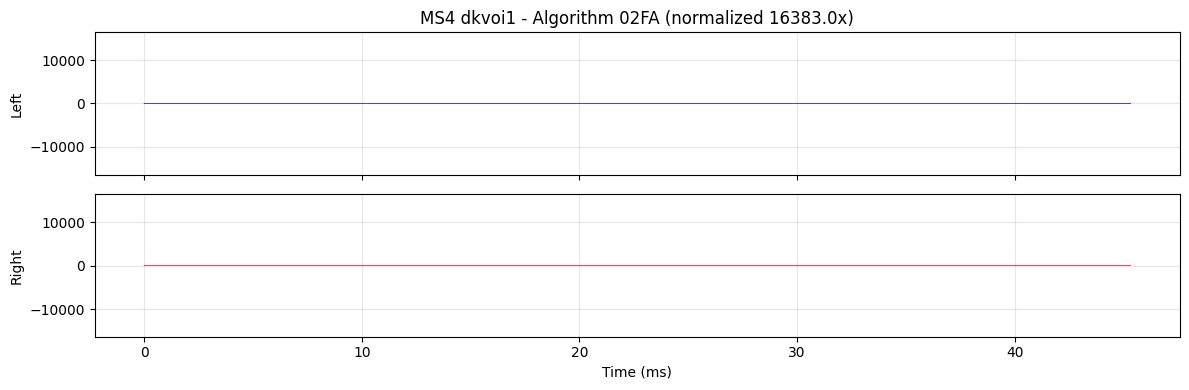

In [6]:
# Generate samples
samples = sam.run(2000, active_slots=[0])

print(f"Generated {len(samples)} samples")
print(f"L range: [{samples[:, 0].min()}, {samples[:, 0].max()}]")
print(f"R range: [{samples[:, 1].min()}, {samples[:, 1].max()}]")

plot_waveform(samples, title=f"MS4 {prog['name']} - Algorithm 02FA", normalize=True)
plt.show()

## State Inspection

In [7]:
print_state(sam.state, slot=0)

SAM8905 Register State
  A = 0x00070  (+112)
  B = 0x00000  (+0)
  X = 0x000  (+0)
  Y = 0x064  (+100)
  PHI = 0x858  (2136)
  WF = 0x000
  MUL = 0x00000  (+0)

  CARRY = False
  CLEAR_RQST = True
  INT_MOD = False

  MIX_L = 0  MIX_R = 0
  L_ACC = +0  R_ACC = +0

D-RAM Slot 0:
  D[ 0] = 0x01400  (+5120)
  D[ 1] = 0x44038  (-245704)
  D[ 2] = 0x02618  (+9752)
  D[ 3] = 0x00018  (+24)
  D[ 4] = 0x0323F  (+12863)
  D[ 5] = 0x7F818  (-2024)
  D[ 6] = 0x03FBF  (+16319)
  D[ 7] = 0x0113F  (+4415)
  D[ 8] = 0x00038  (+56)
  D[ 9] = 0x00038  (+56)
  D[10] = 0x00070  (+112)
  D[11] = 0x00018  (+24)
  D[12] = 0x00018  (+24)
  D[13] = 0x00000  (+0)
  D[14] = 0x00000  (+0)
  D[15] = 0x20000  (+131072)


## Instruction Trace

In [8]:
# Reset and enable tracing
sam.reset()
sam.load_aram(aram_02fa, offset=0)
sam.load_dram(0, dram_slot0)

sam.trace_enabled = True
sam.trace_output = []

samples = sam.run(2, active_slots=[0])

print("Instruction trace (2 frames):")
for line in sam.trace_output:
    print(line)

Instruction trace (2 frames):
S00 PC00: 79F5  RM 15, <WXY, WWF, WSP>  -> x=0x00000, y=0x00400, mul=0x00000, mix_l=0x00000, mix_r=0x00000, wf=0x00100
S00 PC01: 38EF  RM 7, <WPHI>  -> phi=0x00022
S00 PC02: 50F7  RM 10, <WXY>  -> x=0x0004D, y=0x00000, mul=0x00000
S00 PC03: 487F  RM 9, <WA>  -> a=0x00038
S00 PC04: 7CBF  RP, <WB>  -> b=0x00000
S00 PC05: 58FD  RM 11, <WWF>  -> wf=0x00000
S00 PC06: 4AD7  RADD 9, <WM, WXY>  -> x=0x00000, y=0x00000, mul=0x00000
S00 PC07: 407F  RM 8, <WA>  -> a=0x00038
S00 PC08: 7CBF  RP, <WB>  -> b=0x00000
S00 PC09: 42CF  RADD 8, <WM, WPHI>  -> phi=0x00000
S00 PC10: 28B7  RM 5, <WB, WXY>  -> b=0x00038, x=0x00000, y=0x00000, mul=0x00000
S00 PC11: 307F  RM 6, <WA>  -> a=0x03FBF
S00 PC12: 2BDF  RADD 5, <WM, WSP>  -> 
S00 PC13: 11EF  RM 2, <WPHI, WSP>  -> phi=0x00000, wf=0x00100
S00 PC14: 60FD  RM 12, <WWF>  -> wf=0x00000
S00 PC15: 086E  RM 1, <WA, WPHI, WACC>  -> a=0x00038, phi=0x00000, l_acc=0x00000, r_acc=0x00000
S00 PC16: 00BF  RM 0, <WB>  -> b=0x01400
S00 PC17

## Notes

### Algorithm 02FA Characteristics

Key differences from 027A and 02BA:

1. **WACC at PC15** - Single output accumulation point
2. **Uses D[11], D[12]** - Additional waveform/parameter words
3. **Two WWF instructions** - PC05 and PC14 for waveform switching
4. **Flags 0x01** - Both programs have simple init (no complex_init flag)

### Programs Using This Algorithm

Only 2 programs:
- **dstring3** (idx 54): String variant
- **dkvoi1** (idx 55): Voice/choir variant

Note: dkvoi2 uses algorithm 02BA instead, suggesting different synthesis approach.